# Solve Train Station Routing Problem with Constrained QAOA

**Apply Fire Opal's constrained QAOA solver to assign trains to conflict-free paths**

Station routing is the problem of assigning trains to routes through a station so that every train receives a good path and no two trains compete for the same platform or track resource. The problem maps naturally onto a Maximum-Weight Independent Set (MWIS) formulation: candidate paths form a conflict graph, heavy paths are rewarded, and selecting two conflicting paths is penalised. Q-CTRL has applied this formulation in [quantum-enhanced rail scheduling](https://q-ctrl.com/case-study/accelerating-the-schedule-for-quantum-enhanced-rail). The version solved here adds grouped hard constraints on top of plain MWIS: every train must be assigned exactly one path, not at most one.

Fire Opal's [built-in QAOA solver](https://docs.q-ctrl.com/fire-opal/execute/run-algorithms/solve-optimization-problems/fire-opal-qaoa-solver) can deliver solutions to this class of problems. This application note covers the following:

- Defining the station-routing problem as MWIS with grouped hard constraints
- Building a reproducible 120-qubit instance (30 trains with 4 candidate paths each)
- Verifying the optimal solution classically with SCIP
- Running the full QAOA pipeline on an IBM QPU and analysing the results

## 1. Introduction

### 1.1 Defining the station-routing problem

Each train contributes a group of candidate paths, and exactly one path must be assigned per train. Each path $i$ is assigned a binary variable $x_i$, equal to 1 if the path is chosen. Each train forms a one-hot group of binary variables, so every constraint has Hamming weight 1. Chosen paths are rewarded by their weight $w_i$, and quadratic penalties $p_{ij}$ discourage assigning conflicting paths (paths that would share a platform or track resource) to nearby trains:

$$C(x) = -\sum_i w_i\, x_i + \sum_{(i,j)\ \text{conflict}} p_{ij}\, x_i x_j,$$

subject to one path selected per train. Minimising $C$ selects a heavy set of paths with few conflicts, which is the MWIS objective, while the one-hot groups guarantee that every train is assigned a path.

### 1.2 Introducing Fire Opal's constrained QAOA solver

QAOA is a variational quantum algorithm often applied to combinatorial optimisation problems. It alternates parameterised cost and mixer layers on a quantum circuit, and a classical optimiser tunes the layer parameters to steer the sampled distribution towards low-cost bitstrings.

A common way to handle constraints in QAOA is to add penalty terms to the cost function, which wastes shots on infeasible bitstrings. Fire Opal's constrained QAOA solver takes the constraints as a separate input instead: each one-hot group is passed through the `constraint` argument of `solve_qaoa`, the cost function stays free of penalty terms, and a constrained post-processor is applied to the sampled bitstrings, so the distributions analysed in section 5 contain only feasible solutions.

## 2. Imports and initialization

This notebook relies only on public packages. If you do not already have them installed, you can install them with:

```
pip install fire-opal qctrl-visualizer pyscipopt sympy
```

In [ ]:
import os

import matplotlib.pyplot as plt
import numpy as np
from pyscipopt import Model
from sympy import Poly, symbols

import fireopal as fo
import qctrlvisualizer as qv

plt.style.use(qv.get_qctrl_style())

### 2.1 Helper functions

The functions below set up the classical baseline, evaluate bitstring costs, and analyse the Fire Opal results. The one-hot groups are declared as a `constraint` dictionary, where every group of variable indices must sum to exactly 1.

In [4]:
def solve_classically(cost: Poly, constraint_dict: dict) -> tuple[str, float]:
    """Exactly minimise the cost polynomial subject to the one-hot groups with SCIP."""
    model = Model("station_routing")
    model.hideOutput(True)
    variable_count = len(cost.gens)
    x = {i: model.addVar(name=f"x_{i}", vtype="B") for i in range(variable_count)}

    objective = 0
    for exponents, coeff in cost.terms():
        product = 1
        for index, power in enumerate(exponents):
            if power:
                product = product * x[index]
        objective += float(coeff) * product

    for group in constraint_dict:
        model.addCons(sum(x[i] for i in group) == 1)

    # SCIP objectives must be linear, so minimise an auxiliary variable pinned to the cost.
    z = model.addVar(name="cost", vtype="C", lb=None, ub=None)
    model.addCons(z == objective)
    model.setObjective(z, sense="minimize")
    model.optimize()

    bitstring = "".join(
        "1" if model.getVal(x[i]) > 0.5 else "0" for i in range(variable_count)
    )
    return bitstring, model.getObjVal()


def _cost_terms(cost: Poly):
    """Split the polynomial into constant, linear, and quadratic coefficient arrays."""
    n = len(cost.gens)
    const = 0.0
    linear = np.zeros(n)
    qi, qj, qc = [], [], []
    for exponents, coeff in cost.terms():
        indices = [k for k, power in enumerate(exponents) if power]
        value = float(coeff)
        if not indices:
            const += value
        elif len(indices) == 1:  # x^2 == x for binary variables
            linear[indices[0]] += value
        else:
            qi.append(indices[0])
            qj.append(indices[1])
            qc.append(value)
    return const, linear, np.array(qi, dtype=int), np.array(qj, dtype=int), np.array(qc)


def _bit_matrix(bitstrings, cost: Poly, index_map: dict | None = None):
    """Stack bitstrings into an (m, n) 0/1 array in generator (variable) order."""
    n = len(cost.gens)
    raw = np.frombuffer("".join(bitstrings).encode("ascii"), dtype=np.uint8)
    raw = raw.reshape(len(bitstrings), n) - ord("0")
    perm = [index_map[str(g)] for g in cost.gens] if index_map else list(range(n))
    return raw[:, perm]


def evaluate_costs(bitstrings, cost: Poly, index_map: dict | None = None) -> np.ndarray:
    """Vectorised numerical cost evaluation for many bitstrings (no sympy.subs)."""
    const, linear, qi, qj, qc = _cost_terms(cost)
    v = _bit_matrix(bitstrings, cost, index_map)
    costs = const + v @ linear
    if qc.size:
        costs = costs + (v[:, qi] * v[:, qj]) @ qc
    return costs


def cost_of(bitstring: str, cost: Poly, index_map: dict | None = None) -> float:
    """Evaluate the cost polynomial for a single bitstring."""
    return float(evaluate_costs([bitstring], cost, index_map)[0])


def is_feasible(
    bitstring: str, constraint_dict: dict, index_map: dict | None = None
) -> bool:
    """Check that exactly one variable is selected within each one-hot group."""

    def bit(index):
        return int(
            bitstring[index_map[f"x[{index}]"]] if index_map else bitstring[index]
        )

    return all(sum(bit(i) for i in group) == 1 for group in constraint_dict)


def get_cost_distribution(distribution, cost, index_map=None):
    """Return costs and probabilities for a bitstring-count distribution."""
    shot_count = sum(distribution.values())
    costs = evaluate_costs(list(distribution), cost, index_map)
    probabilities = np.array([count / shot_count for count in distribution.values()])
    return costs, probabilities


def random_feasible_bitstrings(constraint_dict, length, count, rng_seed=0):
    """Sample bitstrings that select exactly one variable per one-hot group."""
    rng = np.random.default_rng(seed=rng_seed)
    matrix = np.zeros((count, length), dtype=np.uint8)
    for group in constraint_dict:
        matrix[np.arange(count), rng.choice(list(group), size=count)] = 1
    return ["".join(map(str, row)) for row in matrix]


def plot_cost_distribution(
    distribution, cost, constraint_dict, index_map, optimal_cost=None
):
    """Compare the QAOA cost distribution against random feasible sampling."""
    shot_count = sum(distribution.values())
    length = len(cost.gens)

    qaoa_costs, qaoa_probs = get_cost_distribution(distribution, cost, index_map)
    random_bitstrings = random_feasible_bitstrings(constraint_dict, length, shot_count)
    random_costs = evaluate_costs(random_bitstrings, cost)
    random_probs = np.ones(shot_count) / shot_count

    lower = min(qaoa_costs.min(), random_costs.min())
    upper = max(qaoa_costs.max(), random_costs.max())
    bins = np.linspace(lower, upper, 40)

    _, ax = plt.subplots(1, 1)
    ax.hist(
        [qaoa_costs, random_costs],
        bins,
        weights=[qaoa_probs, random_probs],
        label=["Fire Opal QAOA solver", "Random feasible sampling"],
        color=[qv.QCTRL_STYLE_COLORS[0], qv.QCTRL_STYLE_COLORS[1]],
    )
    if optimal_cost is not None:
        ax.axvline(
            optimal_cost,
            color="black",
            linestyle="--",
            label=f"Optimal ({optimal_cost:.3f})",
        )
    ax.set_xlabel("Cost")
    ax.set_ylabel("Probability")
    ax.legend()
    plt.show()

## 3. Setting up the problem

### 3.1 Building the problem instance

Path weights and conflicts are drawn from a seeded random generator, so the instance is fully reproducible. Conflicts are only generated between trains within `conflict_window` of each other in the ordering, which keeps the coupling graph sparse, as expected for a station where only nearby movements compete for the same resources. Within that window, each path pair conflicts with probability `conflict_prob` and receives a random penalty weight.

In [5]:
def build_station_routing(
    n_trains, paths_per_train=4, conflict_prob=0.45, conflict_window=2, seed=13
):
    """Assign one path per train (MWIS); penalise conflicting nearby paths.

    Returns the cost polynomial and the one-hot constraint dictionary.
    """
    rng = np.random.default_rng(seed)
    n = n_trains * paths_per_train
    path_weight = rng.uniform(0.5, 1.0, size=n)

    x = symbols([f"x[{i}]" for i in range(n)])
    expr = 0
    for i in range(n):
        expr -= path_weight[i] * x[i]  # reward chosen paths (MWIS)
    # Sparse conflicts only between nearby trains.
    for train_a in range(n_trains):
        for train_b in range(train_a + 1, min(train_a + 1 + conflict_window, n_trains)):
            for path_a in range(paths_per_train):
                for path_b in range(paths_per_train):
                    if rng.random() < conflict_prob:
                        i = train_a * paths_per_train + path_a
                        j = train_b * paths_per_train + path_b
                        expr += rng.uniform(0.5, 1.5) * x[i] * x[j]

    # Each train forms a one-hot group: exactly one of its paths is selected.
    constraint_dict = {
        tuple(range(t * paths_per_train, (t + 1) * paths_per_train)): 1
        for t in range(n_trains)
    }
    return Poly(expr, *x), constraint_dict

The instance below uses 30 trains with 4 candidate paths each, for a total of 120 qubits.

In [6]:
cost, constraint_dict = build_station_routing(
    n_trains=30, paths_per_train=4
)  # 120 qubits

qubit_count = len(cost.gens)
print(f"qubits={qubit_count} constraints={len(constraint_dict)}")
print(f"constraint group sizes={set(len(group) for group in constraint_dict)}")

qubits=120 constraints=30
constraint group sizes={4}


### 3.2 Verifying the optimum with SCIP

Because this problem is still within the bounds of what can be solved by classical methods, it is possible to check the accuracy of the solution obtained with the QAOA solver. The exact optimum is computed by solving the binary quadratic program directly with SCIP (via PySCIPOpt), which guarantees global optimality for the non-convex objective. `cost_of` scores arbitrary bitstrings against the same objective.

In [7]:
optimal_bitstring, optimal_cost = solve_classically(cost, constraint_dict)

print(f"SCIP optimal cost = {optimal_cost:.4f}")
print(f"feasible          = {is_feasible(optimal_bitstring, constraint_dict)}")
print(f"evaluator cost    = {cost_of(optimal_bitstring, cost):.4f}")

SCIP optimal cost = -23.9784
feasible          = True
evaluator cost    = -23.9784


## 4. Running the algorithm

### 4.1 Credentials and backend

The Fire Opal QAOA solver runs on an IBM backend. To run it, you need an [IBM Quantum account](https://quantum.cloud.ibm.com/). The solver requires access to IBM Session execution mode, which is only available on a paid IBM Quantum plan. Set up your IBM Cloud credentials and choose a backend below.

In [ ]:
# Authenticate Fire Opal account with your Q-CTRL API key (or via environment variable).
api_key = "YOUR_QCTRL_API_KEY"
fo.authenticate_qctrl_account(api_key=api_key)

# Provide your IBM Cloud API key and instance CRN here (or via environment variables).
token = os.environ.get("IBM_QE_TOKEN", "YOUR_IBM_CLOUD_API_KEY")
instance = os.environ.get("IBM_QE_CRN", "YOUR_IBM_CRN")

credentials = fo.credentials.make_credentials_for_ibm_cloud(
    token=token, instance=instance
)

In [ ]:
# Enter your desired IBM backend here.
backend_name = "ibm_boston"

### 4.2 Running on the QPU

`solve_qaoa` runs the full pipeline on hardware: compilation, iterative parameter optimisation, sampling, and constrained post-processing. The one-hot groups are passed through the `constraint` argument, so the sampled distributions contain only feasible solutions. The printout compares the QAOA cost with the SCIP optimum.

In [ ]:
fire_opal_job = fo.solve_qaoa(
    problem=cost,
    credentials=credentials,
    backend_name=backend_name,
    constraint=constraint_dict,
)
fire_opal_solution = fire_opal_job.result()

In [9]:
print(f"solution bitstring = {fire_opal_solution['solution_bitstring']}")
print(f"QAOA cost          = {fire_opal_solution['solution_bitstring_cost']:.4f}")
print(f"SCIP optimal cost  = {optimal_cost:.4f}")

solution bitstring = 100000101000001000010001001010000100100001000100000101000100100001000100010001000010010000010001100010000010001000100010
QAOA cost          = -23.9784
SCIP optimal cost  = -23.9784


## 5. Analysing the results

The plot below compares the cost distribution of the post-processed QAOA output with random feasible sampling, that is, bitstrings that respect the one-hot groups but are otherwise random, with the SCIP optimum shown as a dashed line. This comparison is relevant because a naive QAOA implementation typically yields results that are indistinguishable from random sampling at this problem scale. In a successful run, the QAOA distribution is concentrated well below random sampling, with visible probability mass at or near the optimum.

solution bitstring = 100000101000001000010001001010000100100001000100000101000100100001000100010001000010010000010001100010000010001000100010
solution cost      = -23.9784
feasible           = True


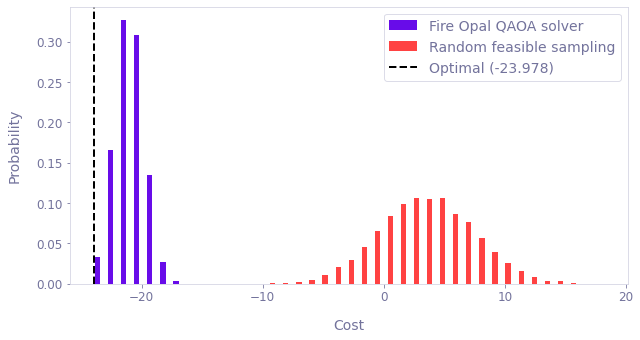

In [37]:
solution_bitstring = fire_opal_solution["solution_bitstring"]
index_map = fire_opal_solution["variables_to_bitstring_index_map"]

print(f"solution bitstring = {solution_bitstring}")
print(f"solution cost      = {cost_of(solution_bitstring, cost, index_map):.4f}")
print(
    f"feasible           = {is_feasible(solution_bitstring, constraint_dict, index_map)}"
)

plot_cost_distribution(
    fire_opal_solution["final_bitstring_distribution"],
    cost,
    constraint_dict,
    index_map,
    optimal_cost=optimal_cost,
)

You have successfully used Fire Opal's constrained QAOA solver to solve a train station-routing problem on quantum hardware. The same structure, an MWIS cost function with one-hot groups declared through the `constraint` argument, serves as a template for applying the solver to other one-hot constrained problems.

In [20]:
fo.print_package_versions()

| Package               | Version |
| --------------------- | ------- |
| Python                | 3.11.5  |
| matplotlib            | 3.10.8  |
| networkx              | 3.6.1   |
| numpy                 | 2.4.6   |
| sympy                 | 1.14.0  |
| fire-opal             | 12.0.0  |
| qctrl-visualizer      | 10.0.0  |
| qctrl-workflow-client | 9.0.1   |
